In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
df = pd.read_csv(url)
df.to_csv('../data/owid_covid_data.csv', index=False)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (429435, 67)
Columns: ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vac

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/owid_covid_data.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nUnique locations:", df['location'].nunique())
print("\nDate range:", df['date'].min(), "to", df['date'].max())

Shape: (429435, 67)

Columns: ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_va

In [5]:
# Check missing values in key columns
key_cols = ['location', 'date', 'total_cases', 'new_cases',
            'total_deaths', 'new_deaths', 'total_vaccinations',
            'people_vaccinated_per_hundred', 'population']

print("Missing values in key columns:")
print(df[key_cols].isnull().sum())
print("\nSample rows:")
df[key_cols].head(10)

Missing values in key columns:
location                              0
date                                  0
total_cases                       17631
new_cases                         19276
total_deaths                      17631
new_deaths                        18827
total_vaccinations               344018
people_vaccinated_per_hundred    348303
population                            0
dtype: int64

Sample rows:


,location,date,total_cases,new_cases,total_deaths,new_deaths,total_vaccinations,people_vaccinated_per_hundred,population
0,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,NaN,NaN,41128772
1,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0,NaN,NaN,41128772
2,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0,NaN,NaN,41128772
3,Afghanistan,2020-01-08,0.0,0.0,0.0,0.0,NaN,NaN,41128772
4,Afghanistan,2020-01-09,0.0,0.0,0.0,0.0,NaN,NaN,41128772
5,Afghanistan,2020-01-10,0.0,0.0,0.0,0.0,NaN,NaN,41128772
6,Afghanistan,2020-01-11,0.0,0.0,0.0,0.0,NaN,NaN,41128772
7,Afghanistan,2020-01-12,0.0,0.0,0.0,0.0,NaN,NaN,41128772
8,Afghanistan,2020-01-13,0.0,0.0,0.0,0.0,NaN,NaN,41128772
9,Afghanistan,2020-01-14,0.0,0.0,0.0,0.0,NaN,NaN,41128772


In [6]:
# The dataset includes rows for continents and world totals
# Filter to actual countries only using the continent column
countries_df = df[df['continent'].notna()].copy()

print("Rows after filtering to countries:", len(countries_df))
print("Unique countries:", countries_df['location'].nunique())

Rows after filtering to countries: 402910
Unique countries: 243


In [7]:
countries_df['date'] = pd.to_datetime(countries_df['date'])
countries_df['year'] = countries_df['date'].dt.year
countries_df['month'] = countries_df['date'].dt.month

print("Data range:", countries_df['date'].min(), "to", countries_df['date'].max())

Data range: 2020-01-01 00:00:00 to 2024-08-14 00:00:00


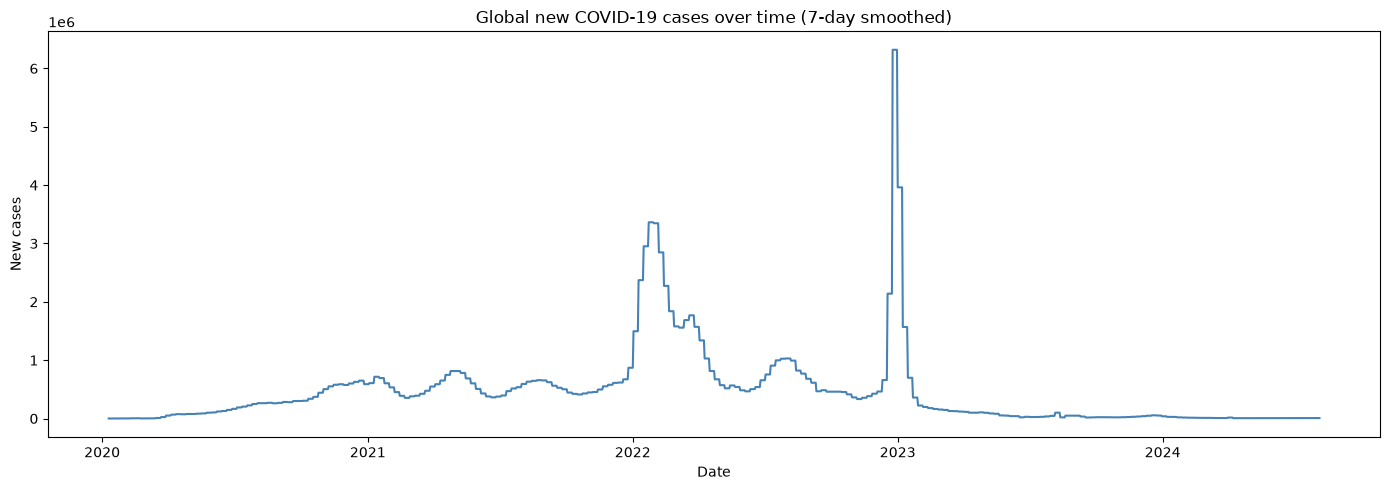

In [9]:
# Get world totals (these are separate rows in the dataset)
world = df[df['location'] == 'World'].copy()
world['date'] = pd.to_datetime(world['date'])

plt.figure(figsize=(14, 5))
plt.plot(world['date'], world['new_cases_smoothed'], color='steelblue', linewidth=1.5)
plt.title('Global new COVID-19 cases over time (7-day smoothed)')
plt.xlabel('Date')
plt.ylabel('New cases')
plt.tight_layout()
plt.savefig('../visuals/01_global_cases.png', dpi=150)
plt.show()